In [1]:
import warnings
warnings.filterwarnings('ignore')

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import datasets
import numpy as np
import pandas as pd

iris = datasets.load_iris()

X = iris.data
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [2]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X)
X = sc.transform(X)

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X)
X = sc.transform(X)

In [4]:
# split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [5]:
from sklearn.linear_model import LogisticRegression

# l1 regularization gives better results
lr = LogisticRegression(penalty='l2', C=10, random_state=0)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
from sklearn import metrics

# generate evaluation metrics
print( "Train - Accuracy :", metrics.accuracy_score(y_train, lr.predict(X_train)))
print( "Train - Confusion matrix :",metrics.confusion_matrix(y_train, lr.predict(X_train)))
print( "Train - classification report :", metrics.classification_report(y_train, lr.predict(X_train)))

print( "Test - Accuracy :", metrics.accuracy_score(y_test, lr.predict(X_test)))
print( "Test - Confusion matrix :",metrics.confusion_matrix(y_test, lr.predict(X_test)))
print( "Test - classification report :", metrics.classification_report(y_test, lr.predict(X_test)))

Train - Accuracy : 0.9809523809523809
Train - Confusion matrix : [[34  0  0]
 [ 0 31  1]
 [ 0  1 38]]
Train - classification report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       0.97      0.97      0.97        32
           2       0.97      0.97      0.97        39

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Test - Accuracy : 0.9777777777777777
Test - Confusion matrix : [[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Test - classification report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.94      0.97        18
           2       0.92      1.00      0.96        11

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98     

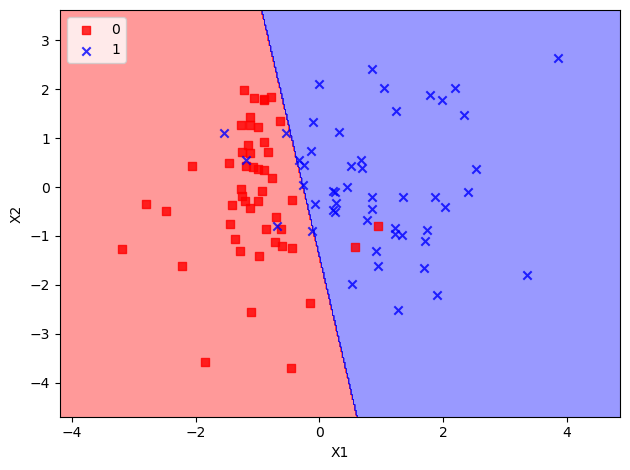

In [7]:
# 1. FIXED: Added all missing imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 2. FIXED: Used explicit keyword arguments for make_classification
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    weights=[.5, .5], 
    random_state=0
) 

# Build a simple logistic regression model
clf = LogisticRegression().fit(X, y)

def plot_decision_regions(X, y, classifier):
    h = .02  # step size in the mesh
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                           np.arange(x2_min, x2_max, h))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        # 3. FIXED: Wrapped c=cmap(idx) in a list to prevent Matplotlib format warnings
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=[cmap(idx)],
                    marker=markers[idx], label=cl)
        
# Plot the decision boundary
plot_decision_regions(X, y, classifier=clf)
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
print (X,y)


[[-7.66054695e-01  1.83324682e-01]
 [-9.20383253e-01 -7.23168038e-02]
 [-9.86585088e-01 -2.86920000e-01]
 [ 1.70910242e+00 -1.10453952e+00]
 [ 1.98764670e+00  1.77624479e+00]
 [ 3.86274219e+00  2.63325914e+00]
 [-1.12836011e+00 -4.22761581e-01]
 [-1.10074198e+00 -2.56042975e+00]
 [-1.53716448e+00  1.10502647e+00]
 [-3.23726922e-01  5.56269743e-01]
 [-1.28532883e+00 -1.30819171e+00]
 [ 3.35973253e+00 -1.79506345e+00]
 [-1.27034986e+00  1.26780440e+00]
 [-7.10233633e-01 -1.13058206e+00]
 [-1.12933108e+00  6.87661760e-01]
 [ 2.48206729e-01 -5.09792713e-01]
 [-2.47263494e+00 -4.86612462e-01]
 [-1.11573423e+00  1.43370121e+00]
 [-1.21414740e+00  1.97698901e+00]
 [-1.25860859e+00 -1.82896522e-01]
 [-5.35834091e-01  1.10698637e+00]
 [ 9.23281451e-01 -1.30813451e+00]
 [ 2.02751248e+00 -4.03257104e-01]
 [ 2.18718140e+00  2.03196825e+00]
 [ 5.12814562e-01  4.32994532e-01]
 [-2.81180710e+00 -3.45538051e-01]
 [ 3.13380666e-01  1.12073484e+00]
 [ 2.72990606e-01 -3.21105367e-01]
 [-1.18986266e+00  4